## Paper Replicating - Vision Transformer
 - https://arxiv.org/abs/2010.11929
 - using pytorch

In [79]:
## Get setup
# For this notebook to run with updated APIs, we need torch 1.12+ and torchvision 0.13+
try:
    import torch
    import torchvision
    assert int(torch.__version__.split(".")[1]) >= 12 or int(torch.__version__.split(".")[0]) == 2, "torch version should be 1.12+"
    assert int(torchvision.__version__.split(".")[1]) >= 13, "torchvision version should be 0.13+"
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
    !pip3 install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")

torch version: 2.6.0
torchvision version: 0.21.0


In [80]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !mv pytorch-deep-learning/helper_functions.py . # get the helper_functions.py script
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves

In [81]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

In [82]:
## Get data
image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                      destination="pizza_steak_sushi")

image_path

[INFO] data/pizza_steak_sushi directory exists, skipping download.


PosixPath('data/pizza_steak_sushi')

In [83]:
train_dir = image_path/"train"
test_dir = image_path/"test"

train_dir , test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [84]:
#set up data loader
from torchvision import transforms
IMAGE_SIZE = 224

manual_transform = transforms.Compose([
    transforms.Resize(size=(IMAGE_SIZE,IMAGE_SIZE)),
    transforms.ToTensor()   
])

manual_transform

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)

In [85]:
BATCH_SIZE = 32

train_data_loader, test_data_loader, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                  test_dir=test_dir,
                                                  transform=manual_transform,
                                                  batch_size=BATCH_SIZE
                                                  )


len(train_data_loader), len(test_data_loader), class_names

(8, 3, ['pizza', 'steak', 'sushi'])

In [86]:
## Visualize a dingle image
# get the first batch of 32
image_batch, label_batch = next(iter(train_data_loader))

In [87]:
# get a a singel image and label

image, label = image_batch[0] , label_batch[0]

image.shape , label.shape

(torch.Size([3, 224, 224]), torch.Size([]))

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

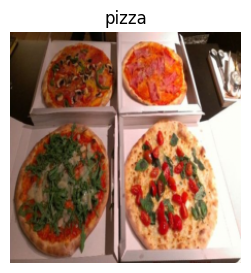

In [88]:
# plot the image with matplot lib
import matplotlib.pyplot as plt

plt.figure(figsize=(5,3))

plt.imshow(image.permute(1,2,0))

plt.title(class_names[label.item()])

plt.axis("off")


In [89]:
image

tensor([[[0.2196, 0.2353, 0.2471,  ..., 0.0667, 0.0745, 0.0824],
         [0.2353, 0.2431, 0.2392,  ..., 0.0667, 0.0745, 0.0824],
         [0.2275, 0.2275, 0.2314,  ..., 0.0706, 0.0667, 0.0745],
         ...,
         [0.4471, 0.4510, 0.4510,  ..., 0.5098, 0.9216, 0.9765],
         [0.4431, 0.4510, 0.4510,  ..., 0.8431, 0.9882, 0.9922],
         [0.4314, 0.4431, 0.4431,  ..., 0.9686, 0.9725, 0.9216]],

        [[0.0863, 0.1020, 0.1176,  ..., 0.0392, 0.0471, 0.0549],
         [0.1137, 0.1176, 0.1176,  ..., 0.0392, 0.0471, 0.0549],
         [0.1176, 0.1176, 0.1216,  ..., 0.0431, 0.0392, 0.0471],
         ...,
         [0.3412, 0.3451, 0.3490,  ..., 0.4745, 0.9098, 0.9647],
         [0.3490, 0.3529, 0.3569,  ..., 0.8275, 0.9765, 0.9843],
         [0.3490, 0.3569, 0.3529,  ..., 0.9686, 0.9608, 0.8980]],

        [[0.0078, 0.0078, 0.0039,  ..., 0.0000, 0.0078, 0.0157],
         [0.0314, 0.0235, 0.0039,  ..., 0.0000, 0.0078, 0.0157],
         [0.0392, 0.0314, 0.0235,  ..., 0.0039, 0.0000, 0.

In [90]:
height = 224 #H
width = 224  #W
color_channel = 3 #C
patch_size = 16 # P

# calculate the number off patchs
# N = HW / P²
num_of_patchs = int((height * width) / patch_size**2)

num_of_patchs # N

196

In [91]:
# Input shape H*W*C
embedding_layer_input_shape = (height , width , color_channel)
# Output shape
embedding_layer_output_shape =  (num_of_patchs , (patch_size**2 * color_channel))

print(f"Inputs shape : {embedding_layer_input_shape}")
print(f"Output shape : {embedding_layer_output_shape}")

Inputs shape : (224, 224, 3)
Output shape : (196, 768)


In [92]:
image

tensor([[[0.2196, 0.2353, 0.2471,  ..., 0.0667, 0.0745, 0.0824],
         [0.2353, 0.2431, 0.2392,  ..., 0.0667, 0.0745, 0.0824],
         [0.2275, 0.2275, 0.2314,  ..., 0.0706, 0.0667, 0.0745],
         ...,
         [0.4471, 0.4510, 0.4510,  ..., 0.5098, 0.9216, 0.9765],
         [0.4431, 0.4510, 0.4510,  ..., 0.8431, 0.9882, 0.9922],
         [0.4314, 0.4431, 0.4431,  ..., 0.9686, 0.9725, 0.9216]],

        [[0.0863, 0.1020, 0.1176,  ..., 0.0392, 0.0471, 0.0549],
         [0.1137, 0.1176, 0.1176,  ..., 0.0392, 0.0471, 0.0549],
         [0.1176, 0.1176, 0.1216,  ..., 0.0431, 0.0392, 0.0471],
         ...,
         [0.3412, 0.3451, 0.3490,  ..., 0.4745, 0.9098, 0.9647],
         [0.3490, 0.3529, 0.3569,  ..., 0.8275, 0.9765, 0.9843],
         [0.3490, 0.3569, 0.3529,  ..., 0.9686, 0.9608, 0.8980]],

        [[0.0078, 0.0078, 0.0039,  ..., 0.0000, 0.0078, 0.0157],
         [0.0314, 0.0235, 0.0039,  ..., 0.0000, 0.0078, 0.0157],
         [0.0392, 0.0314, 0.0235,  ..., 0.0039, 0.0000, 0.

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

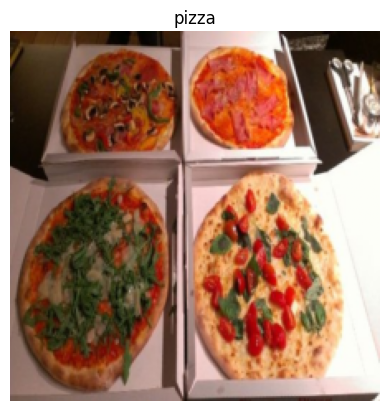

In [93]:
import matplotlib.pyplot as plt

plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis('off')

In [94]:
image.shape

torch.Size([3, 224, 224])

In [95]:
image_permuted = image.permute(1,2,0)

image_permuted.shape

torch.Size([224, 224, 3])

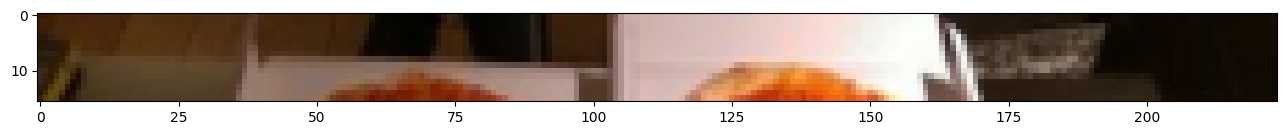

In [96]:
plt.figure(figsize=(16,16))
plt.imshow(image_permuted[:16, :, :])

In [97]:
img_size = 224
patch_size = 16

num_of_patchs = img_size / patch_size

num_of_patchs

14.0

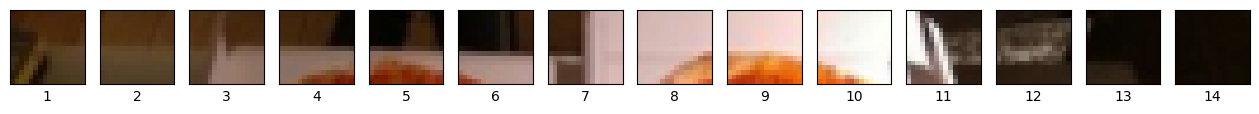

In [98]:
fig, axis = plt.subplots(nrows=1,
                         ncols=img_size // patch_size,
                         figsize = (patch_size, patch_size),
                         sharex=True,
                         sharey=True)



for i, patch in enumerate(range(0,img_size, patch_size)):
    axis[i].imshow(image_permuted[:16, patch:patch+patch_size, :])
    axis[i].set_xlabel(i+1)
    axis[i].set_xticks([])
    axis[i].set_yticks([])

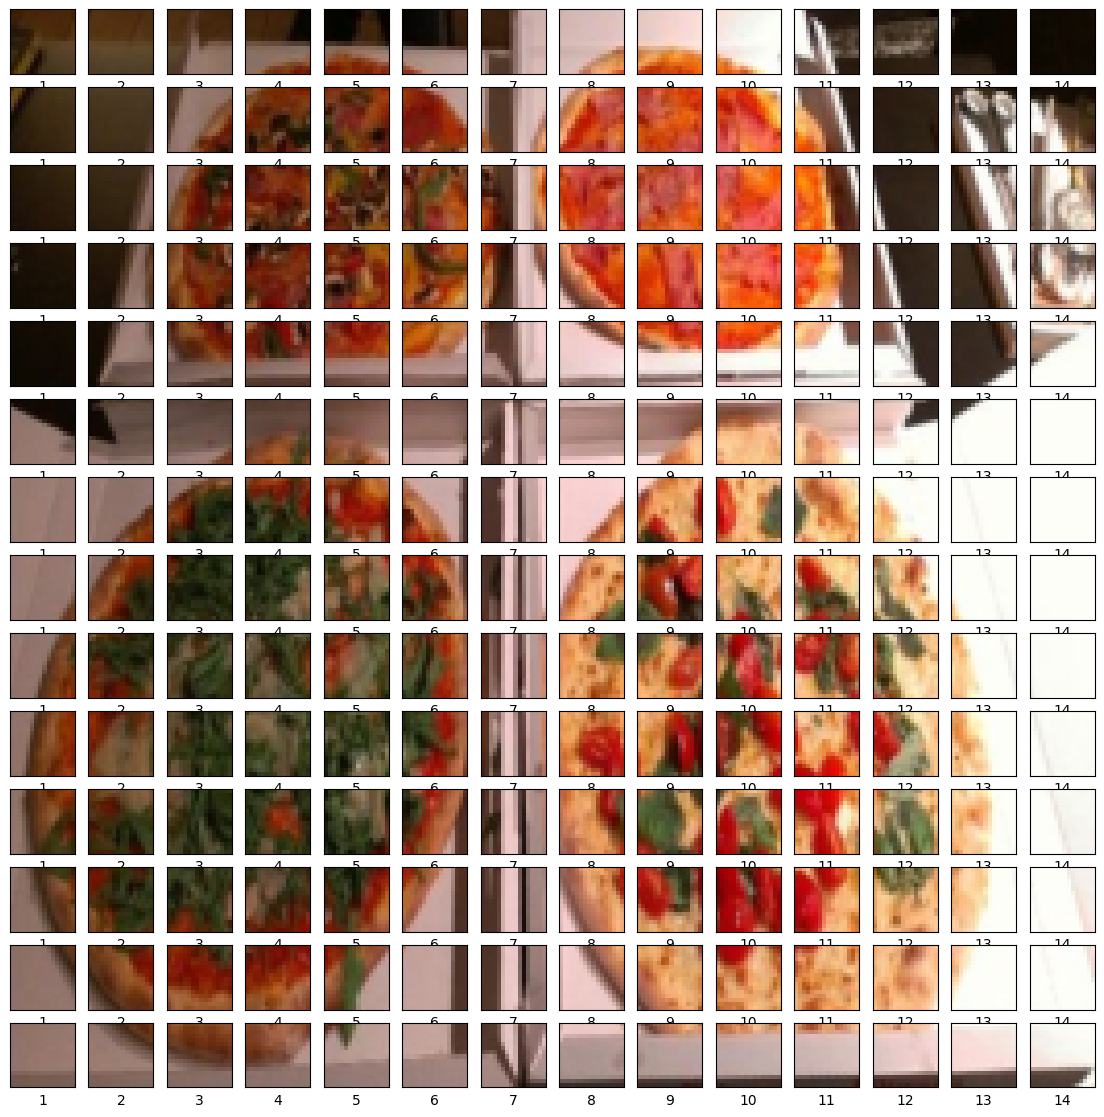

In [99]:
fig, axis = plt.subplots(nrows=img_size // patch_size,
                         ncols=img_size // patch_size,
                         figsize = (num_of_patchs, num_of_patchs),
                         sharex=True,
                         sharey=True)



for i, patch_height in enumerate(range(0,img_size, patch_size)):
    for j, patch_width in enumerate(range(0,img_size, patch_size)):

        axis[i,j].imshow(image_permuted[patch_height:patch_height+patch_size,
                                        patch_width:patch_width+patch_size, :])
        axis[i,j].set_xlabel(j+1)
        axis[i,j].set_xticks([])
        axis[i,j].set_yticks([])